#  Linear regression

In this part, you will implement linear regression with multiple variables to
predict the prices of houses. Suppose you are selling your house and you
want to know what a good market price would be. One way to do this is to
first collect information on recent houses sold and make a model of housing
prices

The fille ex1data2.txt contains a training set of housing prices in Portland, Oregon. The first column is the size of the house (in square feet), the
second column is the number of bedrooms, and the third column is the price
of the house.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('ex1data2.txt', delimiter=',')  # Load the text file with a comma as a delimiter
print(data[0:5,:])

[[2.104e+03 3.000e+00 3.999e+05]
 [1.600e+03 3.000e+00 3.299e+05]
 [2.400e+03 3.000e+00 3.690e+05]
 [1.416e+03 2.000e+00 2.320e+05]
 [3.000e+03 4.000e+00 5.399e+05]]


In [18]:
#load the data a create a np vectors X and y
X = data[:, 0:2]  # Select all rows and first two columns
y = data[:, 2].reshape(-1, 1)   # Select all rows and the last column
print('First 10 examples from the dataset:')
for i in range(10):
     print(f'x = [{X[i, 0]:.0f} {X[i, 1]:.0f}], y = {y[i,0].item():.0f}')


First 10 examples from the dataset:
x = [2104 3], y = 399900
x = [1600 3], y = 329900
x = [2400 3], y = 369000
x = [1416 2], y = 232000
x = [3000 4], y = 539900
x = [1985 4], y = 299900
x = [1534 3], y = 314900
x = [1427 3], y = 198999
x = [1380 3], y = 212000
x = [1494 3], y = 242500


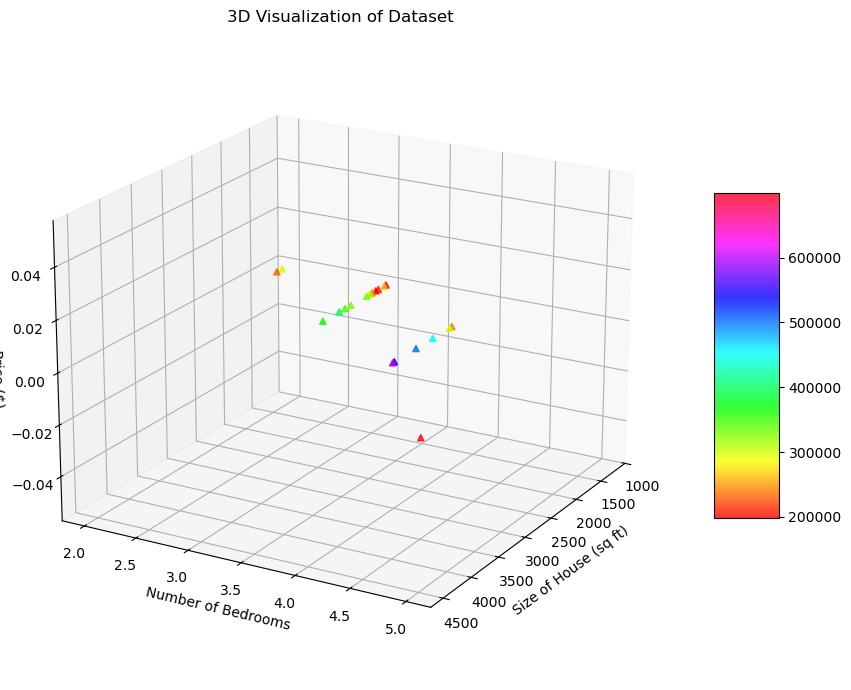

In [ ]:
# ==================== Part 1: Plotting ====================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Plot the points with red x markers
my_cmap = plt.get_cmap('hsv')
sctt = ax.scatter3D(X[0:20, 0], X[0:20, 1],
                    alpha = 0.8,
                    c = y[0:20,0],
                    cmap = my_cmap,
                    marker ='^')
# Label axes
ax.set_xlabel('Size of House (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('Price ($)')
fig.colorbar(sctt, ax = ax, shrink = 0.5, aspect = 5)
# Set grid and view angle similar to MATLAB
ax.view_init(elev=20, azim=30)
ax.grid(True)
plt.title('3D Visualization of Dataset')
plt.tight_layout()
plt.show()

# Feature normalization

Your task here is to complete the code in featureNormalize.m to

*   Subtract the mean value of each feature from the dataset.
*   After subtracting the mean, additionally scale (divide) the feature values
by their respective standard deviations

The mean and std should be:

mu= [2000.68085106    3.17021277], std = [7.94702354e+02 7.60981887e-01]

In [22]:
def featureNormalize(X):
     mu = np.mean(X, axis=0)  # Compute the mean of each feature
     sigma = np.std(X, axis=0)  # Compute the standard deviation of each feature
     X_norm = (X - mu) / sigma  # Normalize the features
     return X_norm, mu, sigma  # Return the normalized features, mean, and standard deviation

[X_norm,mu, sigma] = featureNormalize(X)
print(f'mu= {mu}, std = {sigma}')
print('First 10 examples from the dataset:')
for i in range(10):
     print(f'x = [{X_norm[i, 0]:.4f} {X_norm[i, 1]:.4f}]')
print(X_norm.shape)

mu= [2000.68085106    3.17021277], std = [7.86202619e+02 7.52842809e-01]
First 10 examples from the dataset:
x = [0.1314 -0.2261]
x = [-0.5096 -0.2261]
x = [0.5079 -0.2261]
x = [-0.7437 -1.5544]
x = [1.2711 1.1022]
x = [-0.0199 1.1022]
x = [-0.5936 -0.2261]
x = [-0.7297 -0.2261]
x = [-0.7895 -0.2261]
x = [-0.6445 -0.2261]
(47, 2)


# Cost Function

The objective of linear regression is to minimize the cost function:
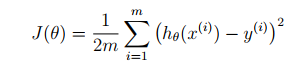

where the hypothesis h is given by

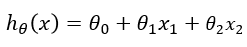




In [ ]:
import numpy as np
from scipy.optimize import minimize

def hypothesis(theta, X):
    return X @ theta
def cost_function(theta, X, y):
    m = len(y)
    h = hypothesis(theta, X)
    error = h - y
    J = (1 / (2 * m)) * np.sum(error ** 2)
    return J
m = X.shape[0]
X_ = np.hstack([np.ones((m, 1)), X_norm])
print(X[0:5,:])
theta = np.zeros((3, 1))
#theta = np.random.randn(3)  # Vector plano de 3 valores aleatorios
print(f"Model parameters: {theta}")
print(f"Cost function: {cost_function(theta, X_, y)}")


[[2.104e+03 3.000e+00]
 [1.600e+03 3.000e+00]
 [2.400e+03 3.000e+00]
 [1.416e+03 2.000e+00]
 [3.000e+03 4.000e+00]]
Model parameters: [[0.]
 [0.]
 [0.]]
Cost function: 65591548106.45744


# Gradient descent

Next, you will implement gradient descent in the file gradientDescent.m.
The loop structure has been written for you, and you only need to supply
the updates to θ within each iteration.

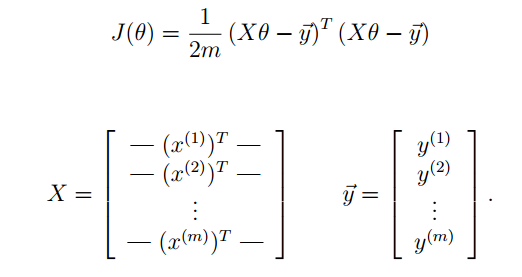

Using the following values:
iterations = 3
theta = np.zeros((2, 1))
alpha = 0.01

The first three iteration:

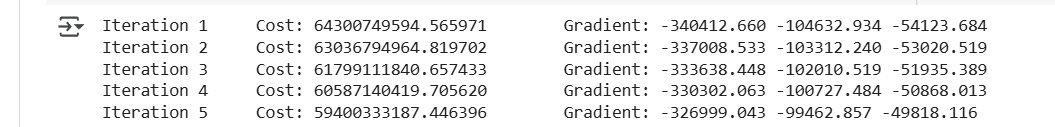

In [ ]:
import numpy as np
from scipy.optimize import minimize
# Gradiente de la función de costo
def cost_gradient(theta, X, y):
    m = len(y)
    theta = theta.reshape(-1, 1)
    h = hypothesis(theta, X)
    grad = 
    # Mostrar en consola la info por iteración
    cost = cost_function(theta, X, y)
    g = grad.flatten()
    print(f"Cost: {cost:.6f} | Gradient: {g[0]:.3f} {g[1]:.3f} {g[2]:.3f}")
    
    return g

# Datos simulados (o usa los tuyos)
# Asegúrate que X, y, mu, sigma están definidos

# Ejemplo de entrada normalizada
X_ = np.hstack([np.ones((X.shape[0], 1)), X])  # Agrega bias
y = y.reshape(-1, 1)
theta_init = np.random.randn(X_.shape[1])  # Vector plano

# Optimización
result = minimize(
    fun=cost_function,
    x0=theta_init,
    args=(X_, y),
    jac=cost_gradient,
    method='BFGS',
    options={'maxiter': 300, 'disp': False}
)

theta = result.x.reshape(-1, 1)
print("\nTheta found by minimize: ", theta.ravel())

# Predicción
input_features = np.array([2000, 3])
normalized_features = (input_features - mu) / sigma
predict1 = np.hstack([1, normalized_features]) @ theta
print(f'Predicted profit for a house with {input_features[0]} sqft and {input_features[1]} bedrooms: ${(predict1 * 10000).item():.2f}')


Iteration 1	Cost: 64300749594.565971	Gradient: -340412.660 -104632.934 -54123.684
Iteration 2	Cost: 63036794964.819702	Gradient: -337008.533 -103312.240 -53020.519
Iteration 3	Cost: 61799111840.657433	Gradient: -333638.448 -102010.519 -51935.389
Iteration 4	Cost: 60587140419.705620	Gradient: -330302.063 -100727.484 -50868.013
Iteration 5	Cost: 59400333187.446396	Gradient: -326999.043 -99462.857 -49818.116
Iteration 6	Cost: 58238154637.679718	Gradient: -323729.052 -98216.361 -48785.425
Iteration 7	Cost: 57100080999.611237	Gradient: -320491.762 -96987.725 -47769.673
Iteration 8	Cost: 55985599971.401474	Gradient: -317286.844 -95776.680 -46770.596
Iteration 9	Cost: 54894210460.017029	Gradient: -314113.976 -94582.964 -45787.934
Iteration 10	Cost: 53825422327.227730	Gradient: -310972.836 -93406.316 -44821.432
Iteration 11	Cost: 52778756141.597954	Gradient: -307863.107 -92246.481 -43870.838
Iteration 12	Cost: 51753742936.324768	Gradient: -304784.476 -91103.208 -42935.905
Iteration 13	Cost: 50

# Visualization

#Selecting learning rates

In this part of the exercise, you will get to try out different learning rates for
the dataset and find a learning rate that converges quickly. You can change
the learning rate and call the function "gradientDescent".

You need to modify "gradientDescent" function and it should also return the history of J(θ) values in a vector J. After the last iteration, the ex1 multi.m script plots the J values against
the number of the iterations.

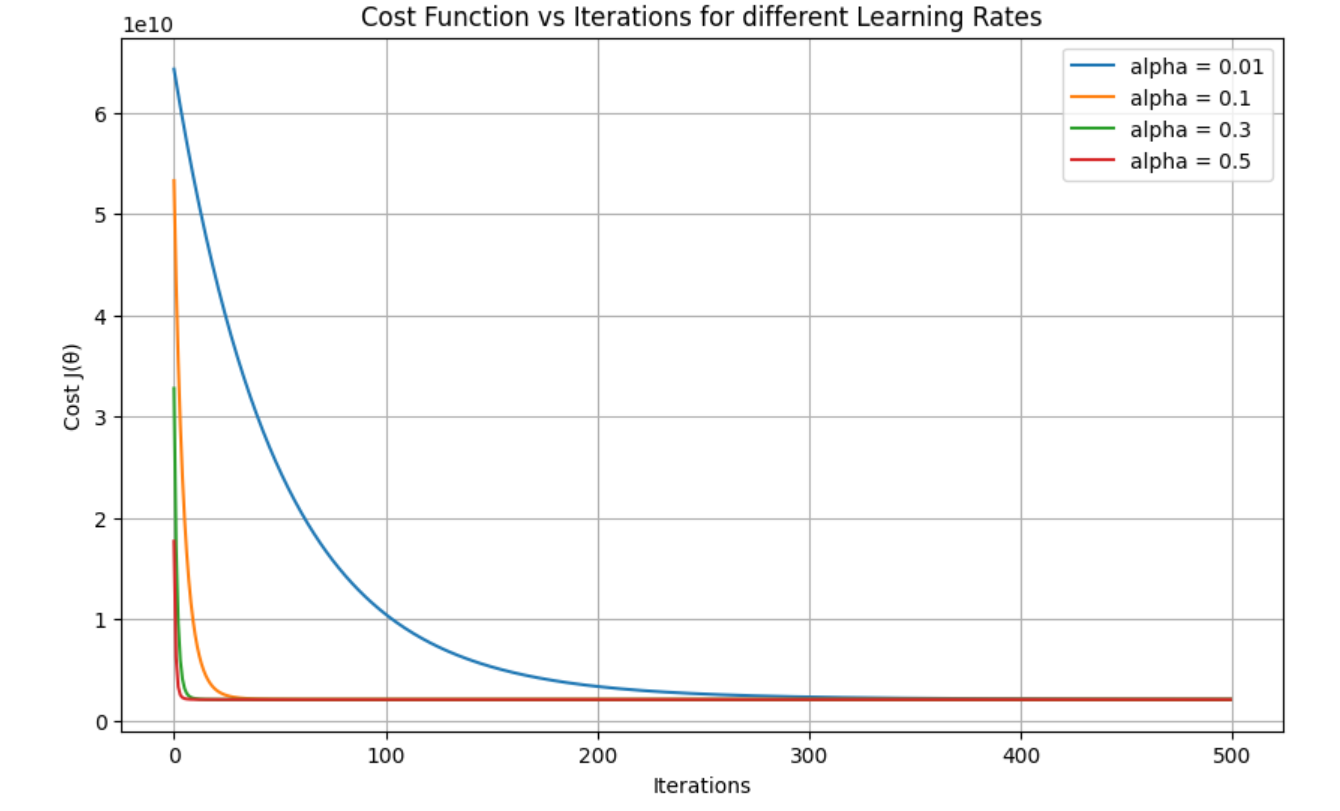

In [1]:
import numpy as np
import matplotlib.pyplot as plt

iterations = 500
theta = np.zeros((3, 1))
alpha_vector = np.array([0.01, 0.1, 0.3, 0.5])
matrix_J = np.zeros((iterations, len(alpha_vector)))

